# eBPF Performance Bottleneck Analysis
Load your `perf_metrics.csv`, explore each metric category, and compare across workload labels.

**Workflow:**
1. Set `CSV_PATH` and `OUT_DIR` in the Config cell
2. Run *Cell 1 (Config)* and *Cell 2 (Load data)* once
3. Run any plot cell independently — no need to re-run everything
4. Use the filter cells to zoom into a specific PID or label

## Cell 1 — Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import numpy as np
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Change these ──────────────────────────────────────────────────────────────
CSV_PATH   = 'perf_metrics.csv'   # path to your CSV
OUT_DIR    = './plots'             # where to save PNGs (set to None to skip saving)
PID_FILTER = None                  # set to an int to filter one PID, e.g. 12345
# ─────────────────────────────────────────────────────────────────────────────

if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
BG    = '#0d1117'
AXES  = '#161b22'
GRID  = '#21262d'
TEXT  = '#c9d1d9'
MUTED = '#484f58'

LABEL_COLORS = {
    'cpu_bound':    '#f87171',
    'memory_bound': '#60a5fa',
    'io_bound':     '#4ade80',
    'contention':   '#fb923c',
    'mixed':        '#c084fc',
    'unknown':      '#6b7280',
}
C = ['#60a5fa','#f87171','#4ade80','#fb923c','#c084fc','#facc15','#34d399','#f472b6']

plt.rcParams.update({
    'figure.facecolor':  BG,   'axes.facecolor':   AXES,
    'axes.edgecolor':    GRID,  'axes.labelcolor':  TEXT,
    'axes.titlecolor':   TEXT,  'xtick.color':      MUTED,
    'ytick.color':       MUTED, 'text.color':       TEXT,
    'grid.color':        GRID,  'grid.linewidth':   0.6,
    'lines.linewidth':   1.4,   'font.family':      'monospace',
    'font.size':         10,    'axes.titlesize':   11,
    'axes.labelsize':    9,     'legend.facecolor': AXES,
    'legend.edgecolor':  GRID,  'legend.labelcolor':TEXT,
    'legend.fontsize':   8,     'savefig.bbox':     'tight',
    'savefig.facecolor': BG,    'savefig.dpi':      150,
})

print('Config ready.')

Config ready.


## Cell 2 — Load & preprocess data

In [2]:
df_raw = pd.read_csv(CSV_PATH)
# df_raw = df_raw.iloc[20:]   # skip first 5 rows (~500ms of startup noise)
df_raw = df_raw[df_raw['timestamp_s'] > df_raw['timestamp_s'].min() + 2]
print(f'Loaded {len(df_raw):,} rows, {len(df_raw.columns)} columns')

# Convert ns columns to µs
for c in [col for col in df_raw.columns if col.endswith('_ns')]:
    df_raw[c.replace('_ns', '_us')] = df_raw[c] / 1000.0

# Derived columns
if 'hw_instructions' in df_raw and 'hw_cycles' in df_raw:
    df_raw['ipc_derived'] = df_raw['hw_instructions'] / df_raw['hw_cycles'].replace(0, float('nan'))
if 'hw_llc_misses' in df_raw and 'hw_llc_refs' in df_raw:
    df_raw['llc_miss_rate'] = df_raw['hw_llc_misses'] / df_raw['hw_llc_refs'].replace(0, float('nan'))

df_raw['t_rel']        = df_raw['timestamp_s'] - df_raw['timestamp_s'].min()
df_raw['total_faults'] = df_raw.get('minor_faults', 0) + df_raw.get('kernel_faults', 0)
df_raw['total_lock_contentions'] = (
    df_raw.get('mutex_contentions', 0) +
    df_raw.get('rwsem_read_contentions', 0) +
    df_raw.get('rwsem_write_contentions', 0)
)

# Apply PID filter
df = df_raw[df_raw['pid'] == PID_FILTER].copy() if PID_FILTER else df_raw.copy()
if PID_FILTER:
    print(f'Filtered to PID {PID_FILTER}: {len(df):,} rows')
print(f'Time range: {df["t_rel"].min():.1f}s – {df["t_rel"].max():.1f}s')
print(f'Labels present: {sorted(df["label"].unique()) if "label" in df.columns else "none"}')
print(f'Unique PIDs: {df["pid"].nunique()}')

Loaded 126,779 rows, 42 columns
Time range: 0.0s – 30.9s
Labels present: ['baseline']
Unique PIDs: 520


## Cell 3 — Optional: filter to a specific label or PID mid-session
Re-run this to change the active filter without reloading. `df` is what all plot cells use.

In [3]:
# Change these and re-run to filter — or set both to None to use all data
FILTER_LABEL = None    # e.g. 'cpu_bound'
FILTER_PID   = None    # e.g. 12345

df = df_raw.copy()
if FILTER_LABEL:
    df = df[df['label'] == FILTER_LABEL]
if FILTER_PID:
    df = df[df['pid'] == FILTER_PID]

print(f'Active dataset: {len(df):,} rows')
if 'label' in df.columns:
    print(df['label'].value_counts().to_string())

Active dataset: 126,779 rows
label
baseline    126779


---
## Helper functions (run once)

In [4]:
def agg_by_time(df, cols, groupby='t_rel'):
    numeric = [c for c in cols if c in df.columns]
    grp = df.groupby(groupby)
    result = grp[numeric].sum()
    if 'label' in df.columns:
        result['label'] = grp['label'].agg(lambda x: x.mode()[0])
    return result.reset_index()

def add_label_bands(ax, df):
    if 'label' not in df.columns or 't_rel' not in df.columns:
        return
    prev_label, start = None, None
    for _, row in df.drop_duplicates('t_rel').sort_values('t_rel').iterrows():
        lbl, t = row['label'], row['t_rel']
        if lbl != prev_label:
            if prev_label is not None:
                ax.axvspan(start, t, alpha=0.08,
                           color=LABEL_COLORS.get(prev_label, MUTED), linewidth=0)
            start, prev_label = t, lbl
    if prev_label and start is not None:
        ax.axvspan(start, df['t_rel'].max(), alpha=0.08,
                   color=LABEL_COLORS.get(prev_label, MUTED), linewidth=0)

def legend_patches(df):
    labels = df['label'].unique() if 'label' in df.columns else []
    return [Patch(color=LABEL_COLORS.get(l, MUTED), alpha=0.6, label=l) for l in labels]

def savefig(fig, name):
    if OUT_DIR:
        path = os.path.join(OUT_DIR, name)
        fig.savefig(path)
        print(f'Saved → {path}')

print('Helpers loaded.')

Helpers loaded.


---
## Figure 1 — CPU Scheduling
- **Top**: context switches split into voluntary (task slept = I/O / lock wait) vs involuntary (task preempted = CPU pressure). High involuntary = CPU bottleneck.
- **Middle**: run queue latency — how long a task waited from wakeup until actually scheduled. Spikes = scheduler contention or oversubscription.
- **Bottom**: CPU migrations — tasks bouncing between cores. High migration = cache thrash.

Saved → ./plots/01_scheduling.png


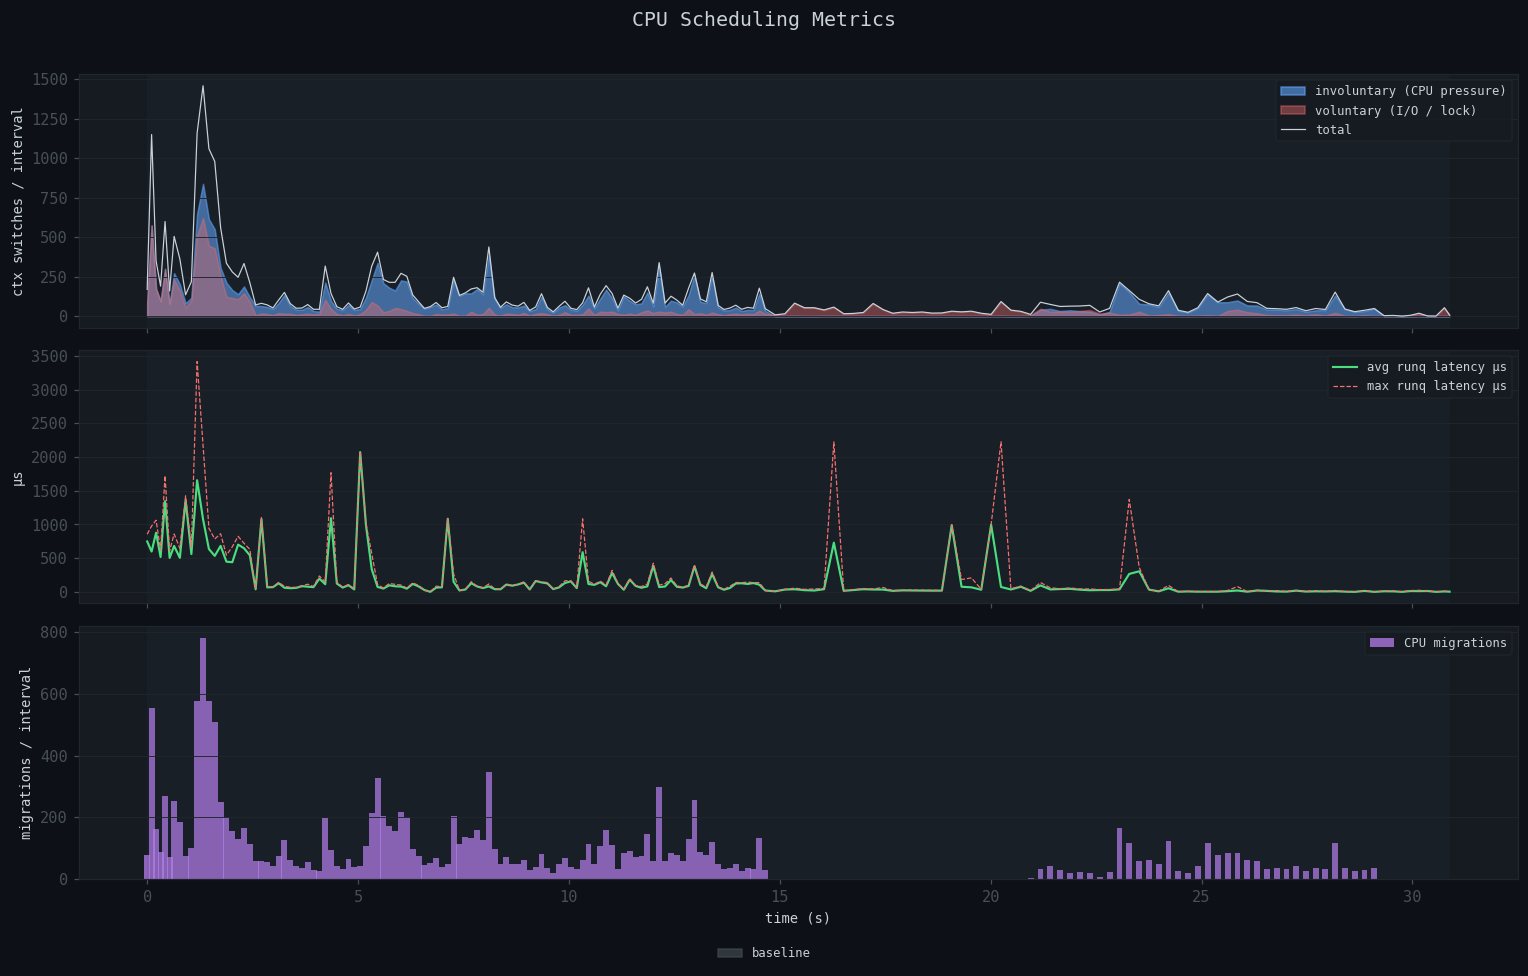

In [5]:
agg = agg_by_time(df, [
    'ctx_switches', 'voluntary_switches', 'involuntary_switches',
    'cpu_migrations', 'avg_runq_latency_us', 'max_runq_latency_us',
])
t = agg['t_rel']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('CPU Scheduling Metrics', fontsize=13, fontweight='normal')

ax = axes[0]
ax.fill_between(t, agg.get('involuntary_switches', 0), alpha=0.6, color=C[0], label='involuntary (CPU pressure)')
ax.fill_between(t, agg.get('voluntary_switches', 0),   alpha=0.4, color=C[1], label='voluntary (I/O / lock)')
ax.plot(t, agg.get('ctx_switches', 0), color=TEXT, linewidth=0.8, label='total')
ax.set_ylabel('ctx switches / interval'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[1]
ax.plot(t, agg.get('avg_runq_latency_us', 0), color=C[2], label='avg runq latency µs')
ax.plot(t, agg.get('max_runq_latency_us', 0), color=C[1], linestyle='--', linewidth=0.8, label='max runq latency µs')
ax.set_ylabel('µs'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[2]
ax.bar(t, agg.get('cpu_migrations', 0), width=t.diff().median(), color=C[4], alpha=0.7, label='CPU migrations')
ax.set_ylabel('migrations / interval'); ax.set_xlabel('time (s)')
ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

patches = legend_patches(df)
if patches:
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
savefig(fig, '01_scheduling.png')
plt.show()

---
## Figure 2 — Memory
- **Top**: page faults. Minor = soft faults (page table fix-up). Kernel = heavier, can indicate kernel memory pressure.
- **Middle**: kmalloc/kfree call rate — high allocation rate with low free rate = potential leak or memory pressure building.
- **Bottom**: bytes allocated per interval + large-page allocs (order > 0) as a memory pressure signal.

Saved → ./plots/02_memory.png


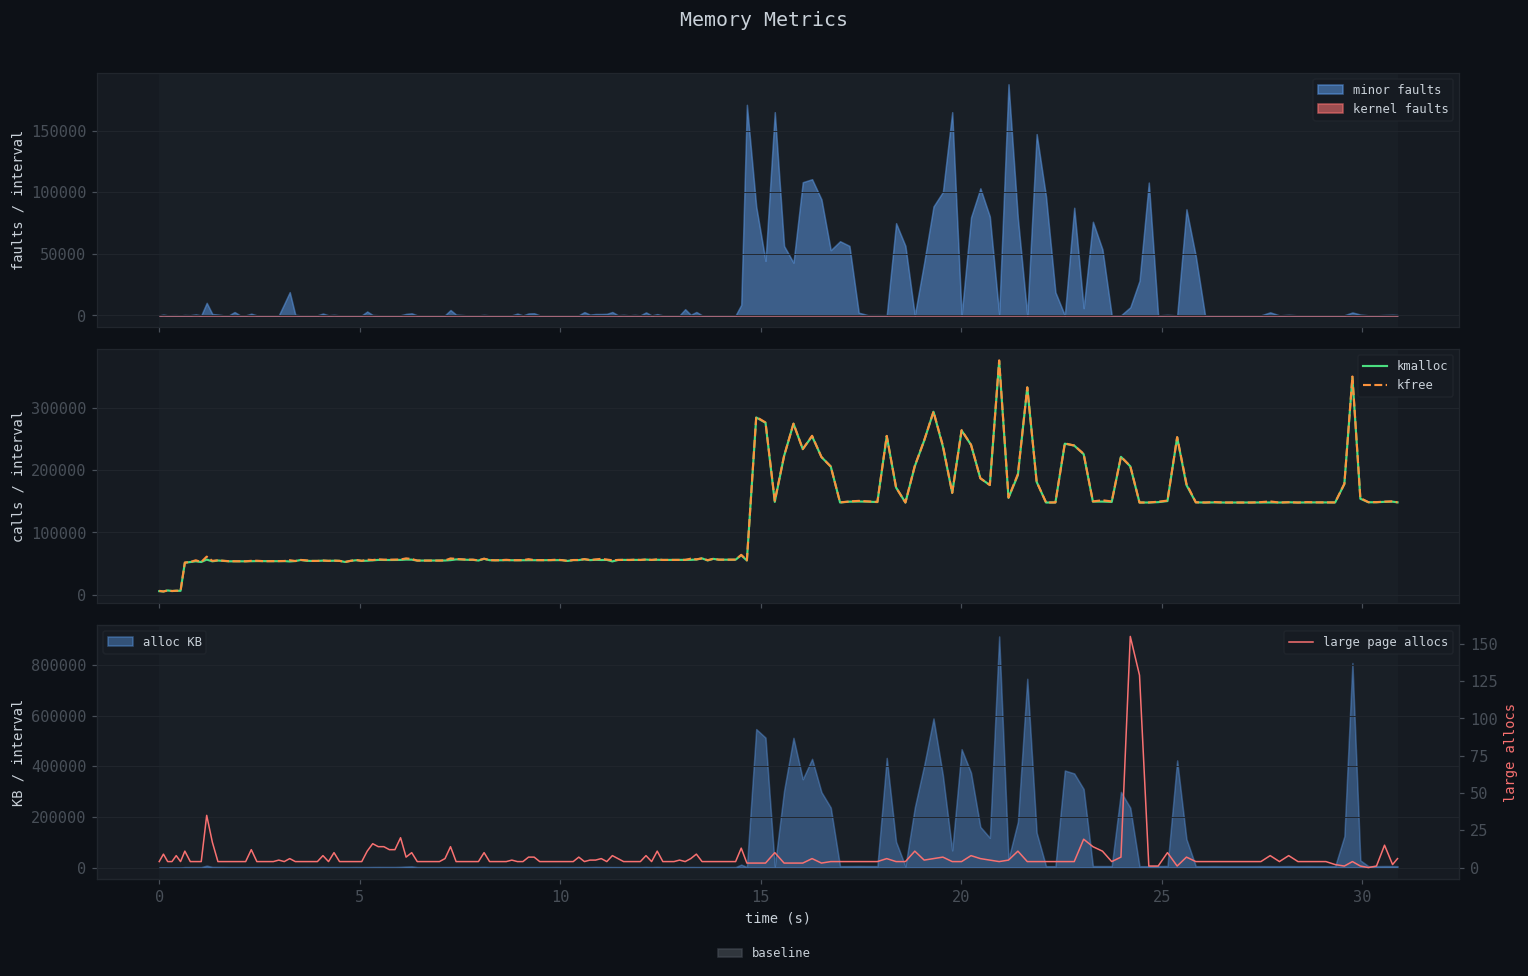

In [6]:
agg = agg_by_time(df, [
    'minor_faults', 'kernel_faults',
    'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'total_free_bytes', 'large_page_allocs',
])
t = agg['t_rel']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Memory Metrics', fontsize=13, fontweight='normal')

ax = axes[0]
ax.fill_between(t, agg.get('minor_faults', 0),  alpha=0.5, color=C[0], label='minor faults')
ax.fill_between(t, agg.get('kernel_faults', 0), alpha=0.6, color=C[1], label='kernel faults')
ax.set_ylabel('faults / interval'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[1]
ax.plot(t, agg.get('kmalloc_count', 0), color=C[2], label='kmalloc')
ax.plot(t, agg.get('kfree_count', 0),   color=C[3], linestyle='--', label='kfree')
ax.set_ylabel('calls / interval'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[2]
ax2 = ax.twinx()
ax.fill_between(t, agg.get('total_alloc_bytes', 0) / 1024, color=C[0], alpha=0.4, label='alloc KB')
ax2.plot(t, agg.get('large_page_allocs', 0), color=C[1], linewidth=1, label='large page allocs')
ax.set_ylabel('KB / interval'); ax2.set_ylabel('large allocs', color=C[1])
ax.set_xlabel('time (s)')
ax.legend(loc='upper left'); ax2.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

patches = legend_patches(df)
if patches:
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
savefig(fig, '02_memory.png')
plt.show()

---
## Figure 3 — Syscall & I/O
- **Top**: latency breakdown — avg of all syscalls vs futex (userspace lock proxy) vs epoll (event loop blocking). High futex latency = lock contention. High epoll = waiting on I/O.
- **Middle**: read/write throughput + error rate.
- **Bottom**: syscall type mix over time — useful to see if the workload shifts from compute to I/O.

Saved → ./plots/03_syscalls.png


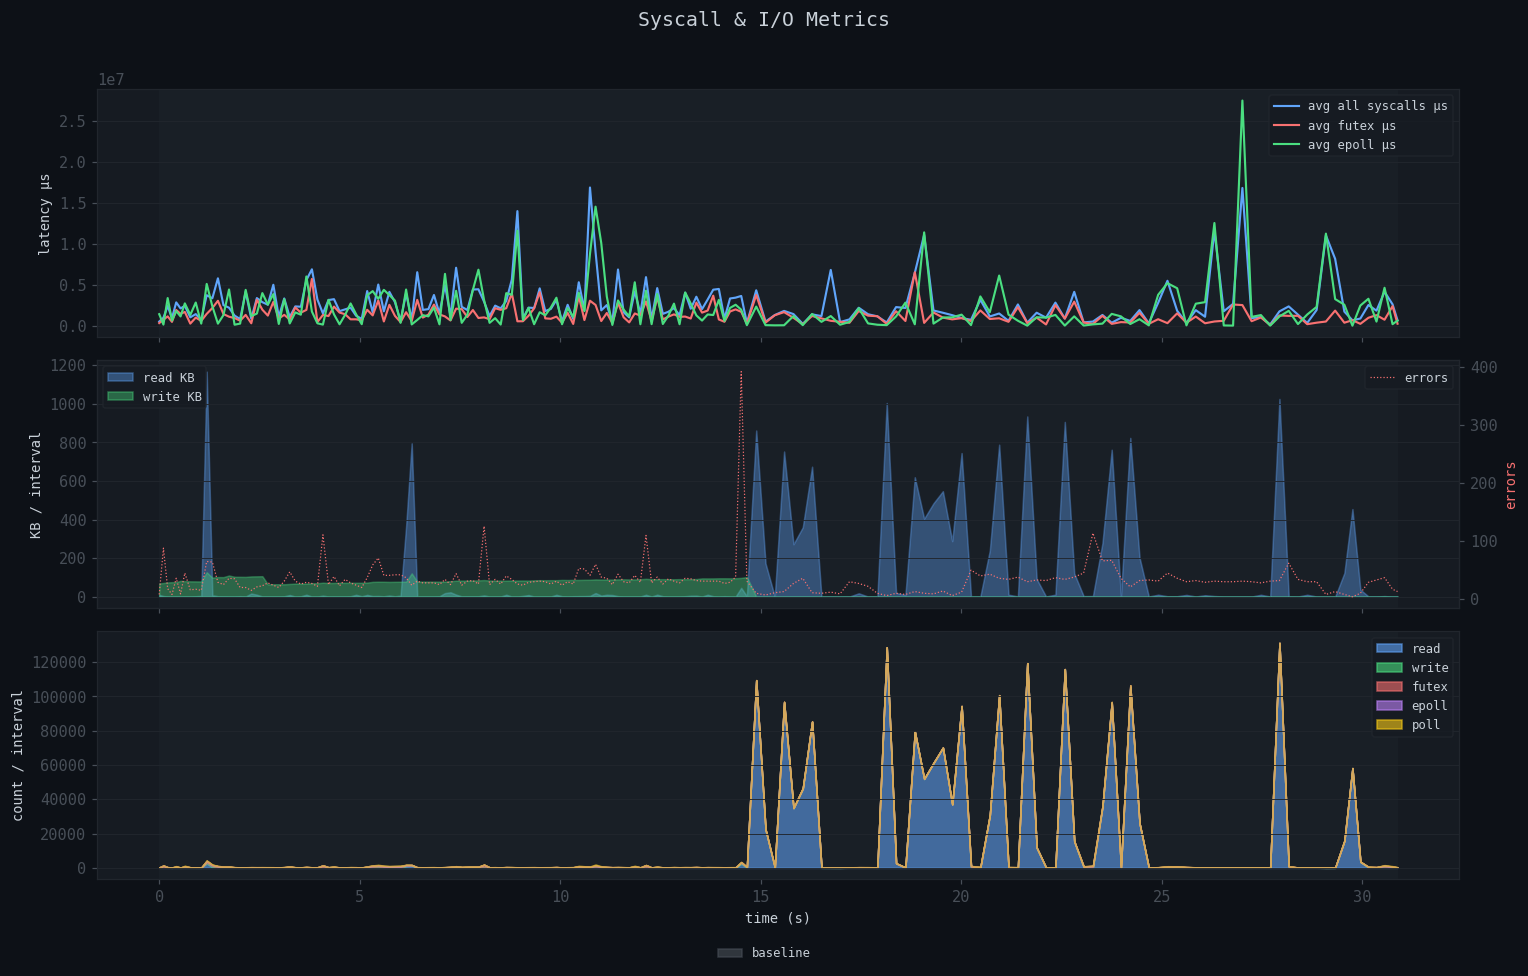

In [7]:
agg = agg_by_time(df, [
    'syscall_count', 'avg_syscall_latency_us', 'max_syscall_latency_us',
    'read_count', 'write_count', 'read_bytes', 'write_bytes',
    'futex_count', 'avg_futex_latency_us',
    'epoll_count', 'avg_epoll_latency_us',
    'poll_count', 'syscall_error_count',
])
t = agg['t_rel']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Syscall & I/O Metrics', fontsize=13, fontweight='normal')

ax = axes[0]
for col, label, color in [
    ('avg_syscall_latency_us', 'avg all syscalls µs', C[0]),
    ('avg_futex_latency_us',   'avg futex µs',        C[1]),
    ('avg_epoll_latency_us',   'avg epoll µs',        C[2]),
]:
    if col in agg.columns:
        ax.plot(t, agg[col], color=color, label=label)
ax.set_ylabel('latency µs'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[1]
ax2 = ax.twinx()
ax.fill_between(t, agg.get('read_bytes', 0)  / 1024, color=C[0], alpha=0.4, label='read KB')
ax.fill_between(t, agg.get('write_bytes', 0) / 1024, color=C[2], alpha=0.4, label='write KB')
ax2.plot(t, agg.get('syscall_error_count', 0), color=C[1], linewidth=0.8, linestyle=':', label='errors')
ax.set_ylabel('KB / interval'); ax2.set_ylabel('errors', color=C[1])
ax.legend(loc='upper left'); ax2.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[2]
bottom = np.zeros(len(t))
for col, color, label in [
    ('read_count',  C[0], 'read'),
    ('write_count', C[2], 'write'),
    ('futex_count', C[1], 'futex'),
    ('epoll_count', C[4], 'epoll'),
    ('poll_count',  C[5], 'poll'),
]:
    vals = agg.get(col, pd.Series(np.zeros(len(t)))).values
    ax.fill_between(t, bottom, bottom + vals, alpha=0.6, color=color, label=label)
    bottom = bottom + vals
ax.set_ylabel('count / interval'); ax.set_xlabel('time (s)')
ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

patches = legend_patches(df)
if patches:
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
savefig(fig, '03_syscalls.png')
plt.show()

---
## Figure 4 — Lock Contention
Only fires on the **slow path** (actual contention). Zero = all locks taken uncontended.
- Mutex: exclusive kernel lock
- rwsem write: writer blocks all readers — heavier than read contention

Saved → ./plots/04_locks.png


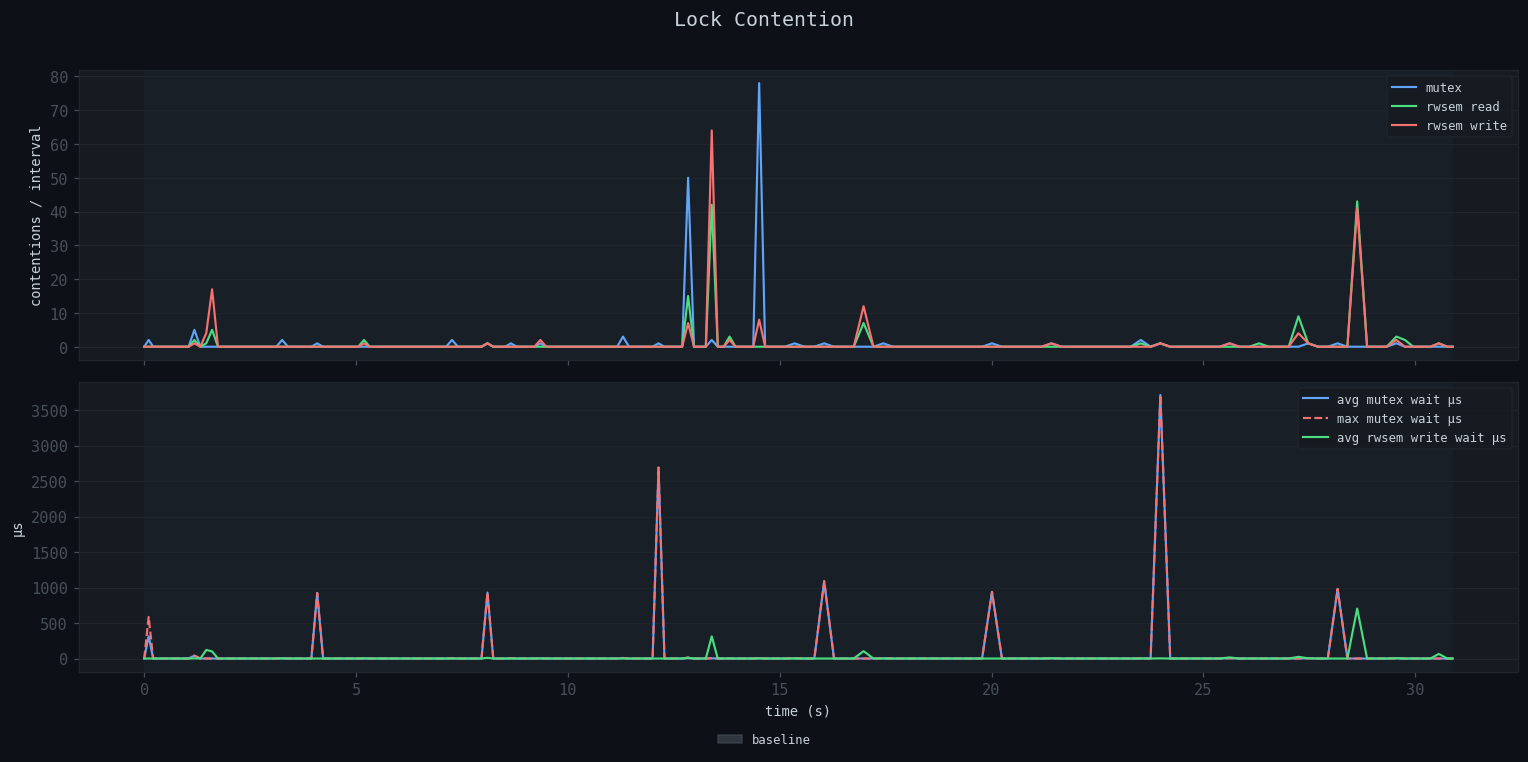

In [8]:
agg = agg_by_time(df, [
    'mutex_contentions', 'avg_mutex_wait_us', 'max_mutex_wait_us',
    'rwsem_read_contentions', 'avg_rwsem_read_wait_us',
    'rwsem_write_contentions', 'avg_rwsem_write_wait_us', 'max_rwsem_write_wait_us',
    'total_lock_contentions',
])
t = agg['t_rel']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Lock Contention', fontsize=13, fontweight='normal')

ax = axes[0]
for col, color, label in [
    ('mutex_contentions',       C[0], 'mutex'),
    ('rwsem_read_contentions',  C[2], 'rwsem read'),
    ('rwsem_write_contentions', C[1], 'rwsem write'),
]:
    if col in agg.columns:
        ax.plot(t, agg[col], color=color, label=label)
ax.set_ylabel('contentions / interval'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

ax = axes[1]
for col, color, label, ls in [
    ('avg_mutex_wait_us',       C[0], 'avg mutex wait µs',       '-'),
    ('max_mutex_wait_us',       C[1], 'max mutex wait µs',       '--'),
    ('avg_rwsem_write_wait_us', C[2], 'avg rwsem write wait µs', '-'),
]:
    if col in agg.columns:
        ax.plot(t, agg[col], color=color, linestyle=ls, label=label)
ax.set_ylabel('µs'); ax.set_xlabel('time (s)')
ax.legend(loc='upper right'); ax.grid(True, axis='y')
add_label_bands(ax, agg)

patches = legend_patches(df)
if patches:
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
savefig(fig, '04_locks.png')
plt.show()

---
## Figure 5 — Hardware Counters (skipped if no hw data)
- **IPC < 1.0** typically means memory-bound (stalled waiting for cache/RAM)
- **High LLC miss rate** confirms memory bottleneck
- **IPC > 3.0** with low misses = pure compute

In [9]:
hw_cols = ['hw_cycles', 'hw_instructions', 'hw_llc_misses', 'hw_llc_refs']
present = [c for c in hw_cols if c in df.columns and df[c].sum() > 0]

if not present:
    print('No hardware counter data in CSV (collector ran with --no-hw or in a VM). Skipping.')
else:
    agg = agg_by_time(df, hw_cols + ['ipc_derived', 'llc_miss_rate'])
    t = agg['t_rel']

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle('Hardware Performance Counters', fontsize=13, fontweight='normal')

    ax = axes[0]
    ax.plot(t, agg.get('hw_cycles', 0) / 1e9,       color=C[0], label='cycles (G)')
    ax.plot(t, agg.get('hw_instructions', 0) / 1e9, color=C[2], label='instructions (G)')
    ax.set_ylabel('× 10⁹ / interval'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
    add_label_bands(ax, agg)

    ax = axes[1]
    ax.plot(t, agg.get('ipc_derived', 0), color=C[3], label='IPC')
    ax.axhline(y=1.0, color=MUTED, linewidth=0.6, linestyle=':')
    ax.set_ylabel('IPC'); ax.legend(loc='upper right'); ax.grid(True, axis='y')
    add_label_bands(ax, agg)

    ax = axes[2]
    ax2 = ax.twinx()
    ax.fill_between(t, agg.get('hw_llc_misses', 0) / 1e6, color=C[1], alpha=0.6, label='LLC misses (M)')
    if 'llc_miss_rate' in agg.columns:
        ax2.plot(t, agg['llc_miss_rate'] * 100, color=C[4], linewidth=0.8, label='miss rate %')
        ax2.set_ylabel('miss rate %', color=C[4]); ax2.legend(loc='upper right')
    ax.set_ylabel('LLC misses (M)'); ax.set_xlabel('time (s)')
    ax.legend(loc='upper left'); ax.grid(True, axis='y')
    add_label_bands(ax, agg)

    patches = legend_patches(df)
    if patches:
        fig.legend(handles=patches, loc='lower center', ncol=len(patches),
                   frameon=False, fontsize=8, bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    savefig(fig, '05_hw_counters.png')
    plt.show()

No hardware counter data in CSV (collector ran with --no-hw or in a VM). Skipping.


---
## Figure 6 — Overview: label distribution, ctx-switch boxplot, correlation heatmap
The **correlation heatmap** is the most useful cell for ML prep — it shows which metrics move together, so you can spot redundant features before training.

Saved → ./plots/06_overview.png


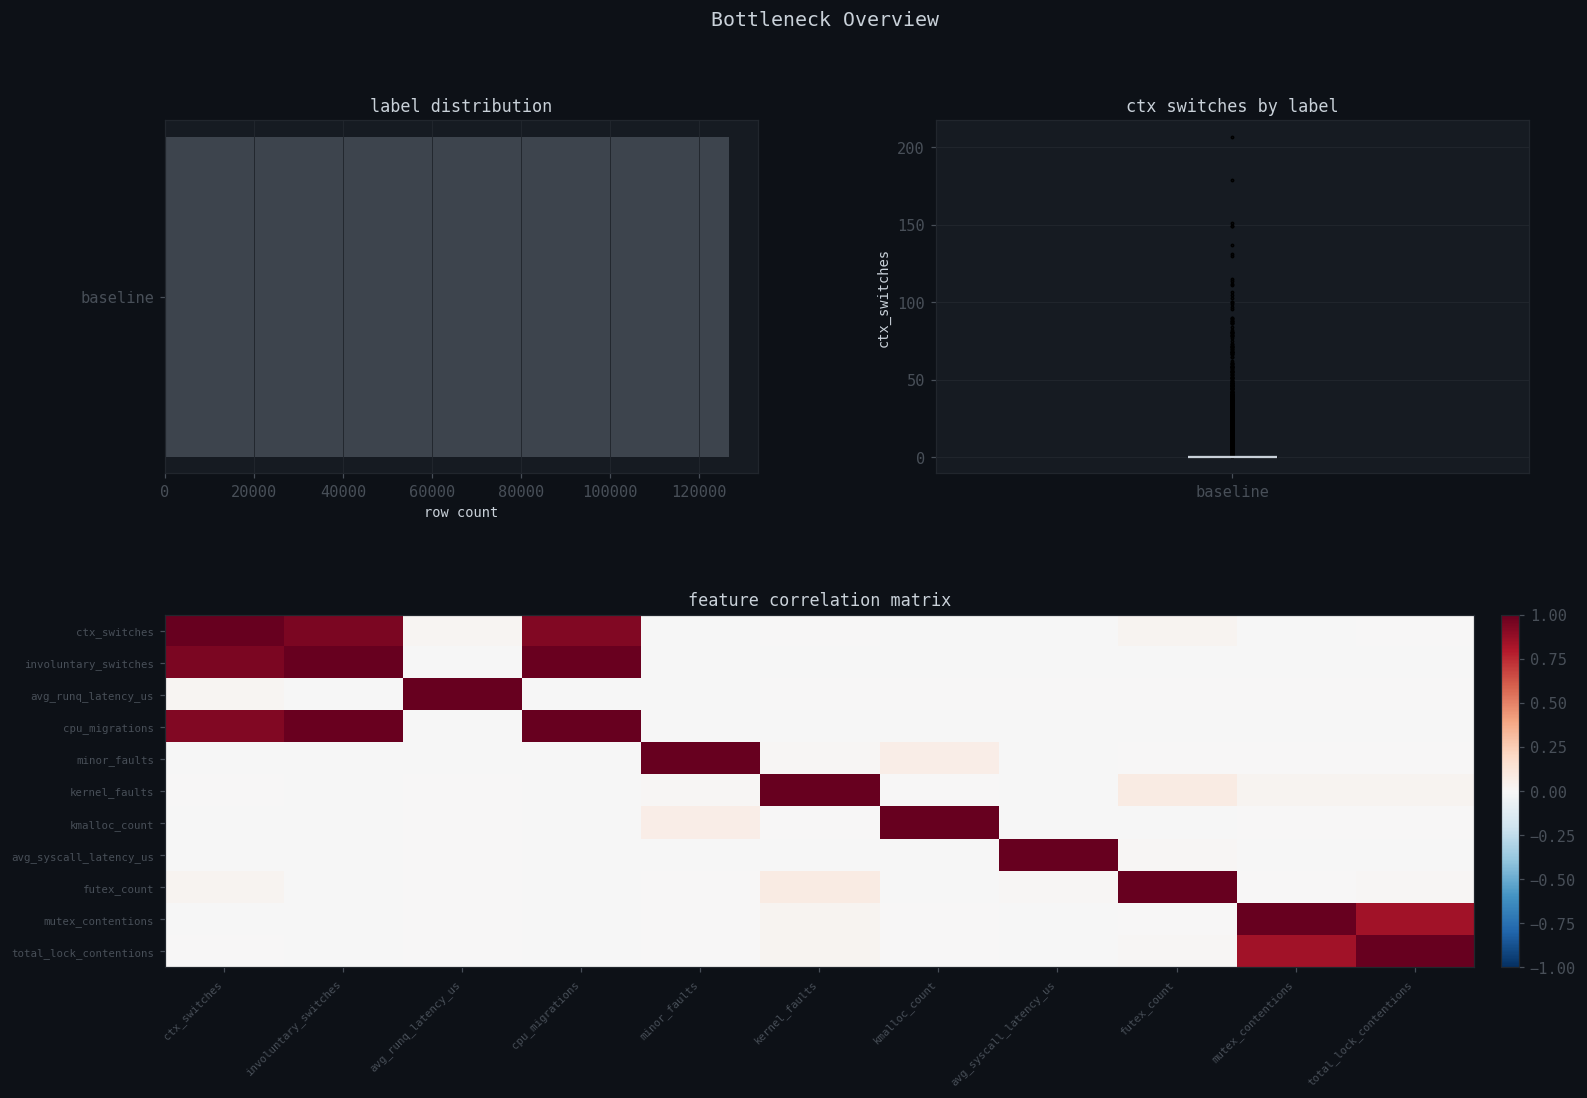

In [10]:
feature_cols = [
    'ctx_switches', 'involuntary_switches', 'avg_runq_latency_us',
    'cpu_migrations', 'minor_faults', 'kernel_faults',
    'kmalloc_count', 'avg_syscall_latency_us', 'futex_count',
    'mutex_contentions', 'total_lock_contentions',
    'hw_llc_misses', 'ipc_derived',
]
present = [c for c in feature_cols if c in df.columns]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle('Bottleneck Overview', fontsize=13, fontweight='normal')

# Label distribution
ax_a = fig.add_subplot(gs[0, 0])
if 'label' in df.columns:
    counts = df['label'].value_counts()
    colors = [LABEL_COLORS.get(l, MUTED) for l in counts.index]
    ax_a.barh(counts.index, counts.values, color=colors, alpha=0.8)
    ax_a.set_xlabel('row count'); ax_a.set_title('label distribution'); ax_a.grid(True, axis='x')

# ctx_switch boxplot by label
ax_b = fig.add_subplot(gs[0, 1])
if 'label' in df.columns and 'ctx_switches' in df.columns:
    labels_sorted = df['label'].unique()
    data = [df[df['label'] == l]['ctx_switches'].dropna().values for l in labels_sorted]
    bp = ax_b.boxplot(data, labels=labels_sorted, patch_artist=True,
                      medianprops={'color': TEXT, 'linewidth': 1.5},
                      boxprops={'linewidth': 0.8},
                      whiskerprops={'linewidth': 0.8},
                      capprops={'linewidth': 0.8},
                      flierprops={'marker': '.', 'markersize': 3})
    for patch, lbl in zip(bp['boxes'], labels_sorted):
        patch.set_facecolor(LABEL_COLORS.get(lbl, MUTED)); patch.set_alpha(0.6)
    ax_b.set_ylabel('ctx_switches'); ax_b.set_title('ctx switches by label'); ax_b.grid(True, axis='y')

# Correlation heatmap
ax_c = fig.add_subplot(gs[1, :])
if len(present) >= 3:
    corr = df[present].corr(numeric_only=True)
    im   = ax_c.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax_c.set_xticks(range(len(present))); ax_c.set_yticks(range(len(present)))
    ax_c.set_xticklabels(present, rotation=45, ha='right', fontsize=7)
    ax_c.set_yticklabels(present, fontsize=7)
    ax_c.set_title('feature correlation matrix')
    plt.colorbar(im, ax=ax_c, fraction=0.02, pad=0.02)

savefig(fig, '06_overview.png')
plt.show()

---
## Figure 7 — Per-label time series comparison
All workload labels overlaid on the same axes for each key metric. This is the main visual for understanding **what makes each bottleneck type distinct**.

Saved → ./plots/07_per_label.png


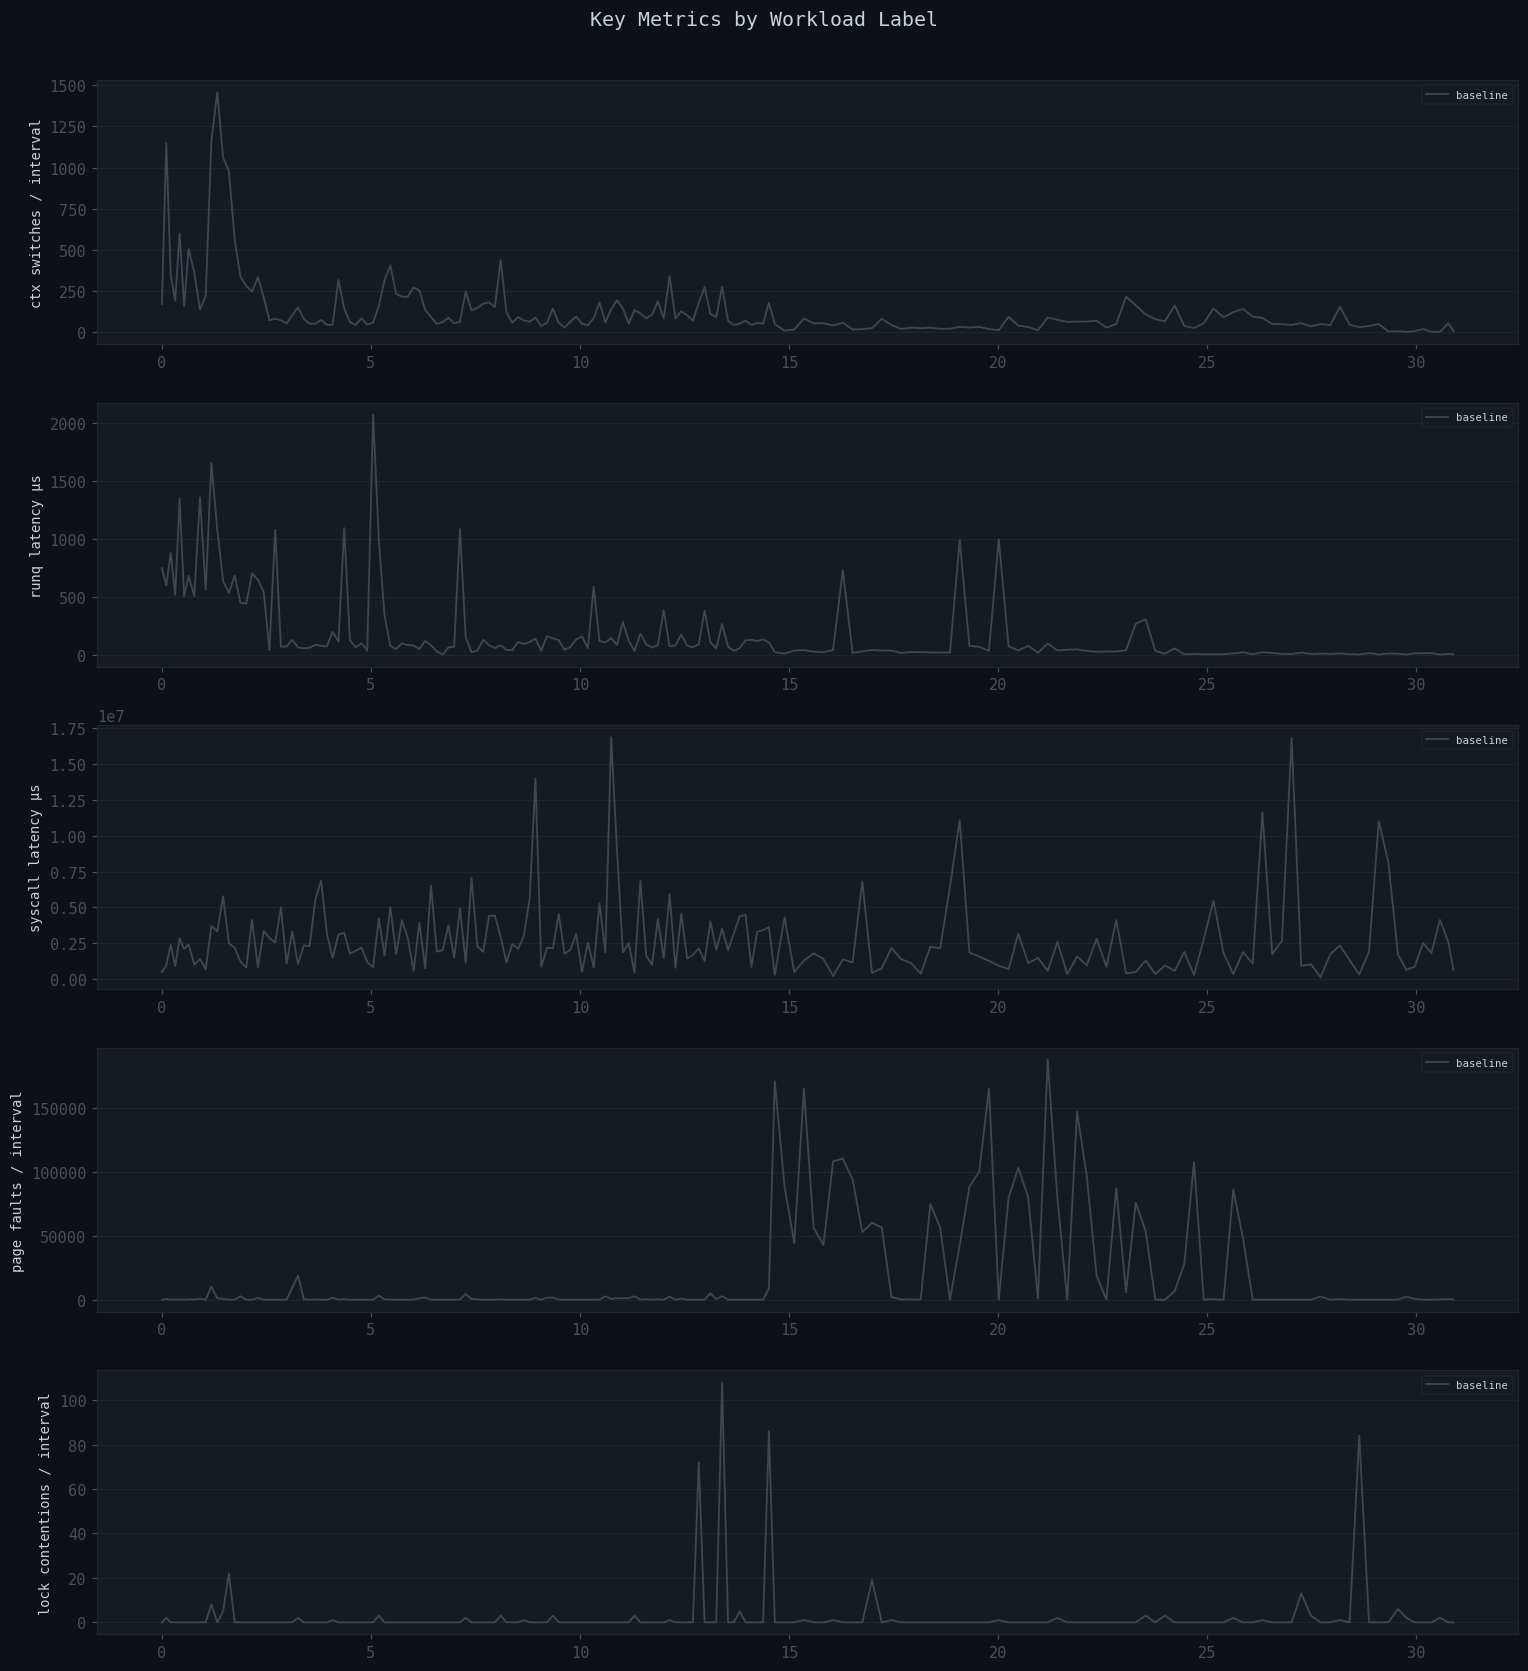

In [11]:
metrics = [
    ('ctx_switches',           'ctx switches / interval'),
    ('avg_runq_latency_us',    'runq latency µs'),
    ('avg_syscall_latency_us', 'syscall latency µs'),
    ('total_faults',           'page faults / interval'),
    ('total_lock_contentions', 'lock contentions / interval'),
]
metrics = [(m, l) for m, l in metrics if m in df.columns]
labels  = sorted(df['label'].unique()) if 'label' in df.columns else []

if not metrics or not labels:
    print('Need labeled data and metric columns to generate this figure.')
else:
    fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 3 * len(metrics)), sharex=False)
    if len(metrics) == 1:
        axes = [axes]
    fig.suptitle('Key Metrics by Workload Label', fontsize=13, fontweight='normal', y=1.01)

    for ax, (col, ylabel) in zip(axes, metrics):
        for lbl in labels:
            sub = df[df['label'] == lbl].sort_values('t_rel')
            if sub.empty: continue
            agg = sub.groupby('t_rel')[col].sum().reset_index()
            ax.plot(agg['t_rel'], agg[col],
                    color=LABEL_COLORS.get(lbl, MUTED), label=lbl, linewidth=1.2, alpha=0.85)
        ax.set_ylabel(ylabel); ax.grid(True, axis='y'); ax.legend(loc='upper right', fontsize=7)

    plt.tight_layout()
    savefig(fig, '07_per_label.png')
    plt.show()

---
## Bonus — Quick stats table per label
Useful sanity check before training: mean ± std per feature per label.

In [12]:
key_cols = [
    'ctx_switches', 'involuntary_switches', 'avg_runq_latency_us',
    'cpu_migrations', 'minor_faults', 'kmalloc_count',
    'avg_syscall_latency_us', 'futex_count', 'mutex_contentions',
]
key_cols = [c for c in key_cols if c in df.columns]

if 'label' in df.columns and key_cols:
    summary = df.groupby('label')[key_cols].agg(['mean', 'std']).round(1)
    display(summary)
else:
    print('No label column or key columns found.')

ctx_switches      involuntary_switches      avg_runq_latency_us  \
                 mean  std                 mean  std                mean   
label                                                                      
baseline          0.2  2.8                  0.1  2.7                 0.3   

               cpu_migrations      minor_faults         kmalloc_count          \
           std           mean  std         mean     std          mean     std   
label                                                                           
baseline  10.0            0.1  2.4         23.5  1271.1         150.2  4015.0   

         avg_syscall_latency_us          futex_count      mutex_contentions  \
                           mean      std        mean  std              mean   
label                                                                         
baseline                 3863.4  89682.2         0.3  4.4               0.0   

               
          std  
label          
baseline  0.2